## Exercise 6 — Four Rooms with Function Approximation

In [14]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import deque

### Four Rooms Environment

In [15]:
class FourRooms(object):
    def __init__(self):
        # define the four room as a 2-D array for easy state space reference and visualization
        # 0 represents an empty cell; 1 represents a wall cell
        self.four_room_space = np.array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

        # find the positions for all empty cells
        empty_cells = np.where(self.four_room_space == 0.0)
        self.state_space = [[col, 10 - row] for row, col in zip(empty_cells[0], empty_cells[1])]

        # define the action space
        self.action_space = {'LEFT': np.array([-1, 0]),
                             'RIGHT': np.array([1, 0]),
                             'DOWN': np.array([0, -1]),
                             'UP': np.array([0, 1])}

        self.start_state = [0, 0]
        self.goal_state = [10, 10]
        self.max_time_steps = 459
        self.t = 0

    def reset(self):
        state = self.start_state
        reward = 0
        done = False
        self.t = 0
        return state, reward, done

    def step(self, state, act):
        self.t += 1
        if np.random.uniform() < 0.2:
            if act == "LEFT" or act == "RIGHT":
                act = np.random.choice(["UP", "DOWN"], 1)[0]
            else:
                act = np.random.choice(["RIGHT", "LEFT"], 1)[0]

        next_state = self.take_action(state, act)
        reward = 1.0 if next_state == [10, 10] else 0.0

        if next_state == [10, 10] or self.t == self.max_time_steps:
            done = True
        else:
            done = False

        return next_state, reward, done

    def take_action(self, state, act):
        state = np.array(state)
        next_state = state + self.action_space[act]
        return next_state.tolist() if next_state.tolist() in self.state_space else state.tolist()

env = FourRooms()
print(f"Number of states: {len(env.state_space)}")
print(f"Number of actions: {len(env.action_space)}")

Number of states: 104
Number of actions: 4


### Helper Functions

In [16]:
def generate_learning_curve(env, encode_func, algo_func, episodes=100, runs=10, **kwargs):
    """Run an algorithm multiple times and collect returns per episode."""
    all_returns = np.zeros((runs, episodes))
    for r in tqdm(range(runs), desc="Runs"):
        returns, _ = algo_func(env, encode_func, episodes=episodes, **kwargs)
        all_returns[r] = returns
    return all_returns

def plot_curves(results_dict, title="Learning Curves"):
    """Plot learning curves with 95% confidence bounds."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlabel("Episodes")
    ax.set_ylabel("Sum of rewards per episode")
    ax.set_title(title)

    for label, data in results_dict.items():
        mean_returns = data.mean(axis=0)
        std_returns = data.std(axis=0)
        se_returns = std_returns / np.sqrt(data.shape[0])  # standard error

        ax.plot(range(data.shape[1]), mean_returns, label=label)
        ax.fill_between(range(data.shape[1]),
                        mean_returns - 1.96 * se_returns,
                        mean_returns + 1.96 * se_returns, alpha=0.2)

    ax.legend()
    plt.tight_layout()
    plt.show()

### Semi-Gradient One-Step SARSA

In [17]:
def semi_gradient_sarsa(env, encode_func, episodes=100, alpha=0.1, gamma=0.99, epsilon=0.1):
    """
    Semi-gradient one-step SARSA with linear function approximation.
    Q(s,a) = w^T * f(s,a)
    Update: w += alpha * [R + gamma * Q(S',A') - Q(S,A)] * f(S,A)
    Works with any feature encoding function.
    """
    # determine feature dimension from a sample encoding
    sample_feature = encode_func(env.start_state, list(env.action_space.keys())[0], env)
    d = len(sample_feature)

    weights = np.zeros(d)
    returns_per_episode = []
    actions = list(env.action_space.keys())

    for ep in range(episodes):
        state, reward, done = env.reset()

        # choose initial action with epsilon-greedy
        if np.random.uniform() < epsilon:
            action = np.random.choice(actions)
        else:
            q_values = [np.dot(weights, encode_func(state, a, env)) for a in actions]
            max_q = np.max(q_values)
            best_actions = [a for a, q in zip(actions, q_values) if q == max_q]
            action = np.random.choice(best_actions)

        G = 0  # sum of rewards in episode

        while not done:
            next_state, reward, done = env.step(state, action)
            G += reward

            if done:
                # terminal: Q(S', A') = 0
                td_target = reward
                next_action = None
            else:
                # choose next action with epsilon-greedy
                if np.random.uniform() < epsilon:
                    next_action = np.random.choice(actions)
                else:
                    q_values = [np.dot(weights, encode_func(next_state, a, env)) for a in actions]
                    max_q = np.max(q_values)
                    best_actions = [a for a, q in zip(actions, q_values) if q == max_q]
                    next_action = np.random.choice(best_actions)
                q_next = np.dot(weights, encode_func(next_state, next_action, env))
                td_target = reward + gamma * q_next

            # semi-gradient SARSA update
            features = encode_func(state, action, env)
            q_hat = np.dot(weights, features)
            td_error = td_target - q_hat
            weights += alpha * td_error * features

            state = next_state
            action = next_action

        returns_per_episode.append(G)

    return returns_per_episode, weights

### Part (a): Tabular State Aggregation with SARSA

Each state is aggregated to itself (no aggregation). The feature for a (state, action) pair is a one-hot vector of dimension $d = N \times M$ where $N$ = number of states, $M$ = number of actions. This means $Q(s,a) = w^T f(s,a) = w_i$, so each weight directly corresponds to one Q-value.

Running Tabular SARSA...


Runs:   0%|          | 0/10 [00:00<?, ?it/s]

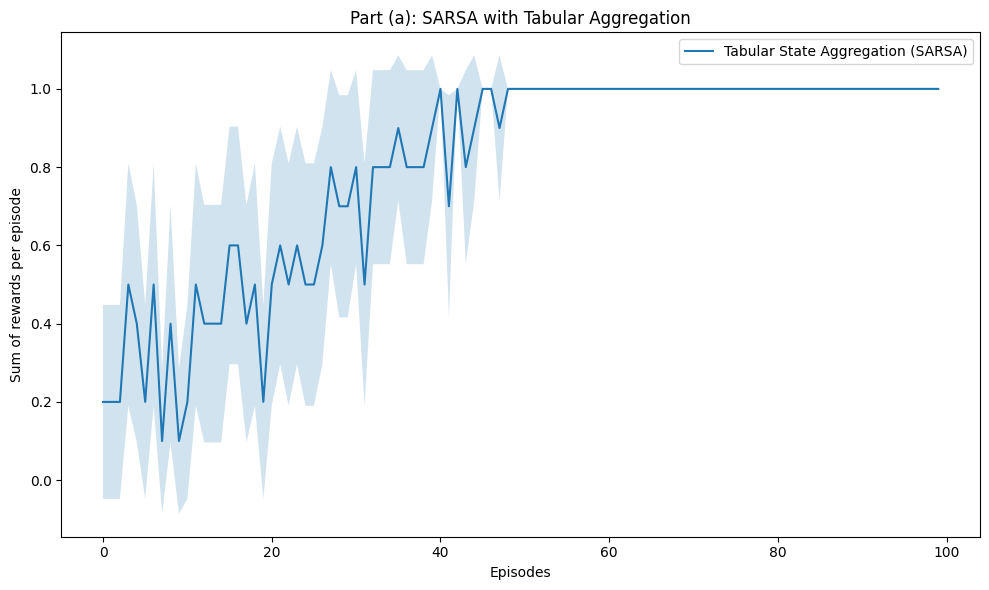

In [18]:
def tabular_feature_encode(state, action, env):
    """
    Tabular one-hot encoding for (state, action) pairs.
    Feature dimension d = |S| * |A|.
    Each (state, action) pair maps to a unique index.
    Q(s,a) = w^T f(s,a) = w_i (just looks up the weight for that pair).
    """
    s_idx = env.state_space.index(state)
    a_idx = list(env.action_space.keys()).index(action)
    num_states = len(env.state_space)
    num_actions = len(env.action_space)

    d = num_states * num_actions
    feature = np.zeros(d)
    hot_idx = s_idx * num_actions + a_idx
    feature[hot_idx] = 1.0
    return feature

# Run tabular SARSA
print("Running Tabular SARSA...")
returns_tabular = generate_learning_curve(
    env, tabular_feature_encode, semi_gradient_sarsa,
    episodes=100, runs=10, alpha=0.1
)

plot_curves({"Tabular State Aggregation (SARSA)": returns_tabular},
            "Part (a): SARSA with Tabular Aggregation")

### Part (b): Tile-based and Room-based State Aggregation

**Tile-based**: Each 2×2 block of cells is aggregated into one state. Coordinates range [0,10], so tile indices = coord // 2, giving 6×6 = 36 possible tiles. Feature dimension = 36 × 4 = 144.

**Room-based**: All states in one room map to one aggregated state. 4 rooms + 1 hallway group (states on x=5 or y=5 boundary). Feature dimension = 5 × 4 = 20.

Running Tile-based SARSA...


Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Running Room-based SARSA...


Runs:   0%|          | 0/10 [00:00<?, ?it/s]

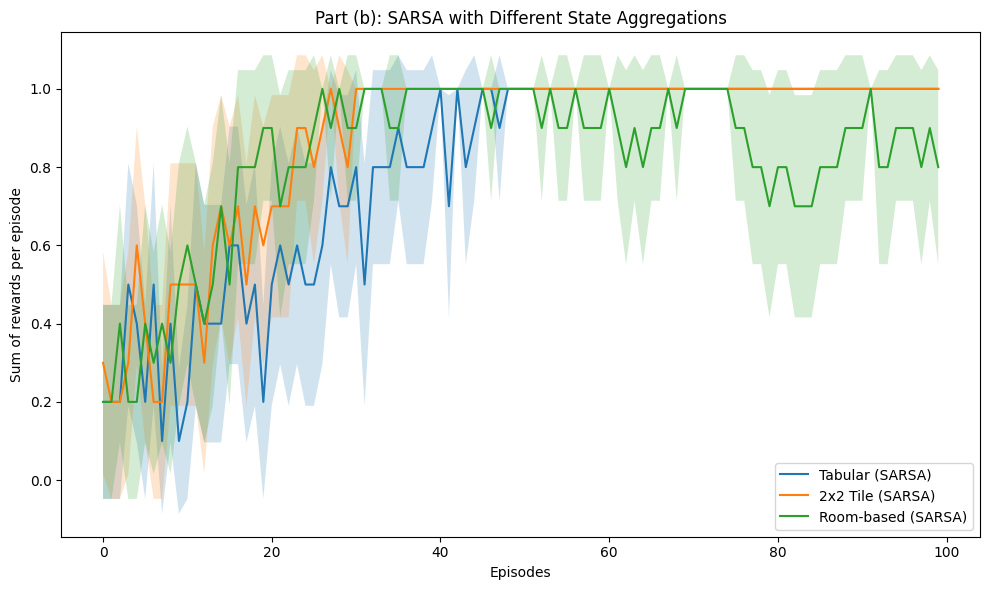

In [19]:
def tile_feature_encode(state, action, env):
    """
    2x2 tile-based state aggregation.
    Aggregates states [0,0],[1,0],[0,1],[1,1] -> tile (0,0), etc.
    Tile index: (x//2, y//2). Max tile index = 5 in each dim -> 6x6=36 tiles.
    One-hot over (tile_id, action) pairs. d = 36 * 4 = 144.
    """
    tile_x = state[0] // 2
    tile_y = state[1] // 2
    tile_id = tile_y * 6 + tile_x  # unique tile identifier (0 to 35)

    a_idx = list(env.action_space.keys()).index(action)
    num_actions = len(env.action_space)

    d = 36 * num_actions
    feature = np.zeros(d)
    hot_idx = tile_id * num_actions + a_idx
    feature[hot_idx] = 1.0
    return feature

def room_feature_encode(state, action, env):
    """
    Room-based state aggregation.
    Room 0 (bottom-left):  x < 5, y < 5
    Room 1 (bottom-right): x > 5, y < 5
    Room 2 (top-left):     x < 5, y > 5
    Room 3 (top-right):    x > 5, y > 5
    Room 4 (hallway):      x = 5 or y = 5 (boundary/doorway cells)
    One-hot over (room_id, action) pairs. d = 5 * 4 = 20.
    """
    x, y = state[0], state[1]

    if x < 5 and y < 5:
        room_id = 0
    elif x > 5 and y < 5:
        room_id = 1
    elif x < 5 and y > 5:
        room_id = 2
    elif x > 5 and y > 5:
        room_id = 3
    else:
        room_id = 4  # hallway / boundary

    num_rooms = 5
    a_idx = list(env.action_space.keys()).index(action)
    num_actions = len(env.action_space)

    d = num_rooms * num_actions
    feature = np.zeros(d)
    hot_idx = room_id * num_actions + a_idx
    feature[hot_idx] = 1.0
    return feature

# Run tile and room SARSA
print("Running Tile-based SARSA...")
returns_tile = generate_learning_curve(
    env, tile_feature_encode, semi_gradient_sarsa,
    episodes=100, runs=10, alpha=0.1
)

print("Running Room-based SARSA...")
returns_room = generate_learning_curve(
    env, room_feature_encode, semi_gradient_sarsa,
    episodes=100, runs=10, alpha=0.1
)

# Plot all three SARSA variants together
plot_curves({
    "Tabular (SARSA)": returns_tabular,
    "2x2 Tile (SARSA)": returns_tile,
    "Room-based (SARSA)": returns_room
}, "Part (b): SARSA with Different State Aggregations")

### Part (c): Semi-Gradient One-Step Q-Learning (Extra Credit)

The key difference from SARSA: the bootstrap target uses the **greedy** action $\max_a Q(S', a)$ rather than the actual next action $Q(S', A')$. This makes Q-learning an **off-policy** method.

Running Q-Learning Tabular...


Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Running Q-Learning Tile...


Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Running Q-Learning Room...


Runs:   0%|          | 0/10 [00:00<?, ?it/s]

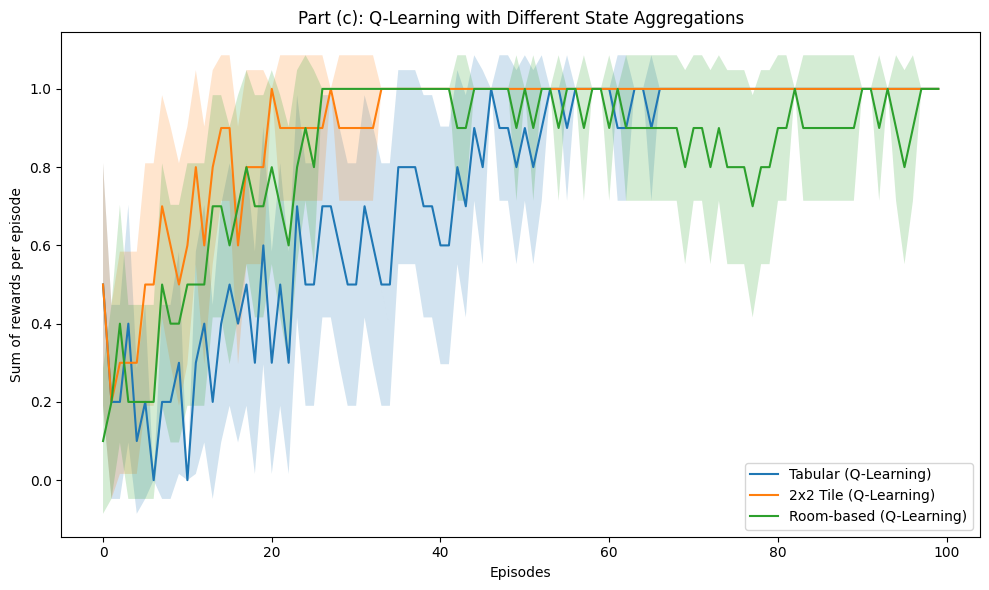

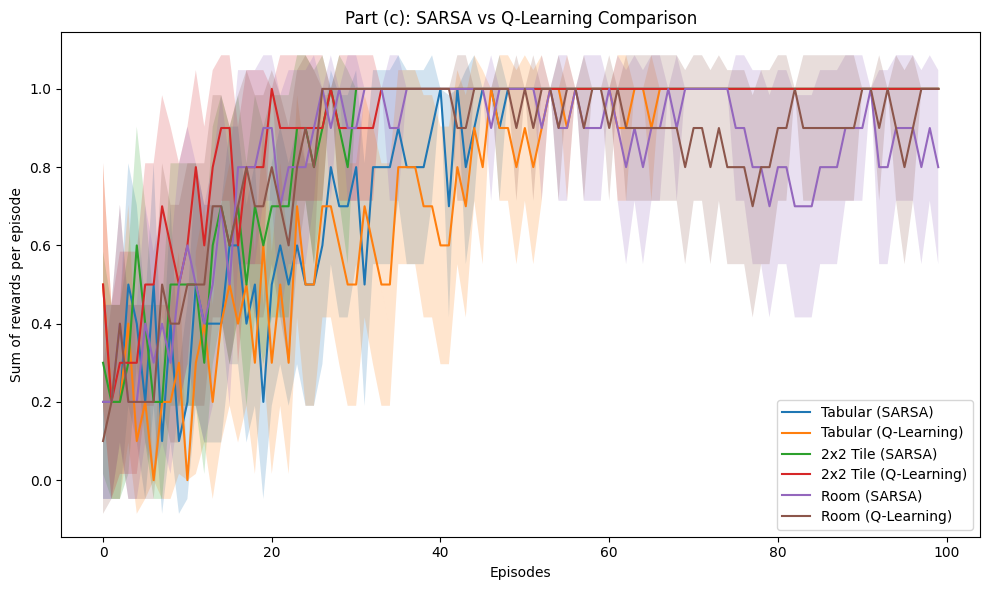

In [20]:
def semi_gradient_q_learning(env, encode_func, episodes=100, alpha=0.1, gamma=0.99, epsilon=0.1):
    """
    Semi-gradient one-step Q-learning with linear function approximation.
    Q(s,a) = w^T * f(s,a)
    Update: w += alpha * [R + gamma * max_a Q(S',a) - Q(S,A)] * f(S,A)
    Key difference from SARSA: uses max over next-state Q-values (greedy target).
    """
    d = len(encode_func(env.start_state, list(env.action_space.keys())[0], env))
    weights = np.zeros(d)
    returns_per_episode = []
    actions = list(env.action_space.keys())

    for ep in range(episodes):
        state, reward, done = env.reset()
        G = 0

        while not done:
            # epsilon-greedy action selection (behavior policy)
            if np.random.uniform() < epsilon:
                action = np.random.choice(actions)
            else:
                q_values = [np.dot(weights, encode_func(state, a, env)) for a in actions]
                max_q = np.max(q_values)
                best_actions = [a for a, q in zip(actions, q_values) if q == max_q]
                action = np.random.choice(best_actions)

            next_state, reward, done = env.step(state, action)
            G += reward

            if done:
                td_target = reward
            else:
                # Q-learning: use MAX over all next-state actions (greedy target)
                q_values_next = [np.dot(weights, encode_func(next_state, a, env)) for a in actions]
                td_target = reward + gamma * np.max(q_values_next)

            # semi-gradient update
            features = encode_func(state, action, env)
            q_hat = np.dot(weights, features)
            td_error = td_target - q_hat
            weights += alpha * td_error * features

            state = next_state

        returns_per_episode.append(G)

    return returns_per_episode, weights

# Run Q-learning with all three encodings
print("Running Q-Learning Tabular...")
returns_tabular_q = generate_learning_curve(
    env, tabular_feature_encode, semi_gradient_q_learning,
    episodes=100, runs=10, alpha=0.1
)

print("Running Q-Learning Tile...")
returns_tile_q = generate_learning_curve(
    env, tile_feature_encode, semi_gradient_q_learning,
    episodes=100, runs=10, alpha=0.1
)

print("Running Q-Learning Room...")
returns_room_q = generate_learning_curve(
    env, room_feature_encode, semi_gradient_q_learning,
    episodes=100, runs=10, alpha=0.1
)

# Plot Q-learning curves
plot_curves({
    "Tabular (Q-Learning)": returns_tabular_q,
    "2x2 Tile (Q-Learning)": returns_tile_q,
    "Room-based (Q-Learning)": returns_room_q
}, "Part (c): Q-Learning with Different State Aggregations")

# Side-by-side comparison: SARSA vs Q-Learning
plot_curves({
    "Tabular (SARSA)": returns_tabular,
    "Tabular (Q-Learning)": returns_tabular_q,
    "2x2 Tile (SARSA)": returns_tile,
    "2x2 Tile (Q-Learning)": returns_tile_q,
    "Room (SARSA)": returns_room,
    "Room (Q-Learning)": returns_room_q
}, "Part (c): SARSA vs Q-Learning Comparison")

### Part (d): Linear Function Approximation with (x, y, 1) Features

Instead of one-hot encoding, we use a compact feature vector $[x, y, 1]$ for each state. To incorporate actions, we create a block-diagonal structure: the full feature vector has dimension $3 \times |A| = 12$. Only the 3 entries for the selected action are non-zero. This gives each action its own set of weights: $Q(s, a_i) = w_{i,1} \cdot x + w_{i,2} \cdot y + w_{i,3}$.

The constant feature (1) serves as a **bias term**, allowing the linear model to learn a non-zero baseline Q-value independent of coordinates.

Running Linear (x,y,1) SARSA...


Runs:   0%|          | 0/10 [00:00<?, ?it/s]

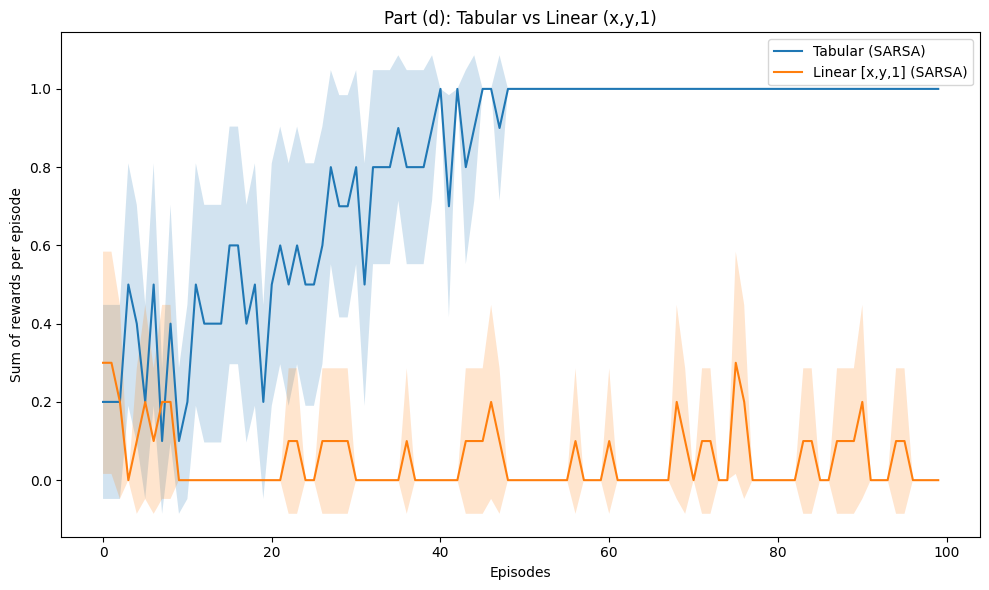

In [ ]:
def linear_xy1_feature_encode(state, action, env):
    """
    Linear function approximation with features [x, y, 1].
    
    Action incorporation: block-diagonal structure.
    Full feature vector has d = 3 * |A| = 12 dimensions.
    For action i, only indices [3*i, 3*i+1, 3*i+2] are non-zero.
    This gives each action separate weights:
        Q(s, action_i) = w_{i,0}*x + w_{i,1}*y + w_{i,2}*1
    """
    x, y = state[0], state[1]
    base_features = np.array([x, y, 1.0])

    a_idx = list(env.action_space.keys()).index(action)
    num_actions = len(env.action_space)

    d = 3 * num_actions  # 3 features * 4 actions = 12
    feature = np.zeros(d)
    feature[a_idx * 3 : (a_idx + 1) * 3] = base_features
    return feature

#use smaller alpha for linear features (larger feature values than one-hot)
print("Running Linear (x,y,1) SARSA...")
returns_linear = generate_learning_curve(
    env, linear_xy1_feature_encode, semi_gradient_sarsa,
    episodes=100, runs=10, alpha=0.01
)

# Compare with tabular
plot_curves({
    "Tabular (SARSA)": returns_tabular,
    "Linear [x,y,1] (SARSA)": returns_linear
}, "Part (d): Tabular vs Linear (x,y,1)")

### Part (e): Normalized Coordinates and Distance Features

**Normalized**: $[x/10, y/10, 1]$ — scales features to [0,1] for more stable learning.

**Distance**: $[d, x, y, 1]$ — adds shortest-path distance to goal as an extra feature, providing the agent with domain knowledge about proximity to the reward.

In [ ]:
def compute_distance_matrix(env):
    """
    BFS shortest distance from every reachable state to the goal.
    Returns dict: (x, y) -> distance (int).
    """
    goal = tuple(env.goal_state)
    distances = {}
    visited = set()
    queue = deque()
    queue.append((goal, 0))
    visited.add(goal)

    while queue:
        current, dist = queue.popleft()
        distances[current] = dist
        for action_vec in env.action_space.values():
            neighbor = (current[0] + action_vec[0], current[1] + action_vec[1])
            if list(neighbor) in env.state_space and neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, dist + 1))

    return distances

#pre compute distances for the standard Four Rooms
distance_matrix = compute_distance_matrix(env)
print(f"Distance from start {env.start_state} to goal: {distance_matrix.get(tuple(env.start_state), 'N/A')}")
print(f"Distance from (5,5) to goal: {distance_matrix.get((5,5), 'N/A')}")

Distance from start [0, 0] to goal: 20
Distance from (5,5) to goal: N/A


Running Normalized [x/10, y/10, 1] SARSA...


Runs:   0%|          | 0/10 [00:00<?, ?it/s]

Running Distance [d, x, y, 1] SARSA...


Runs:   0%|          | 0/10 [00:00<?, ?it/s]

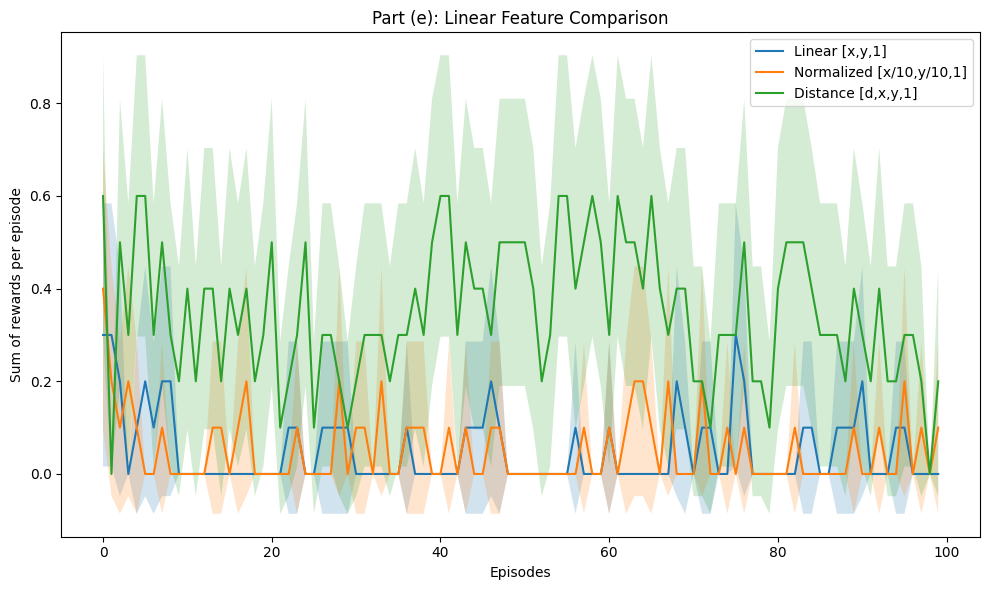

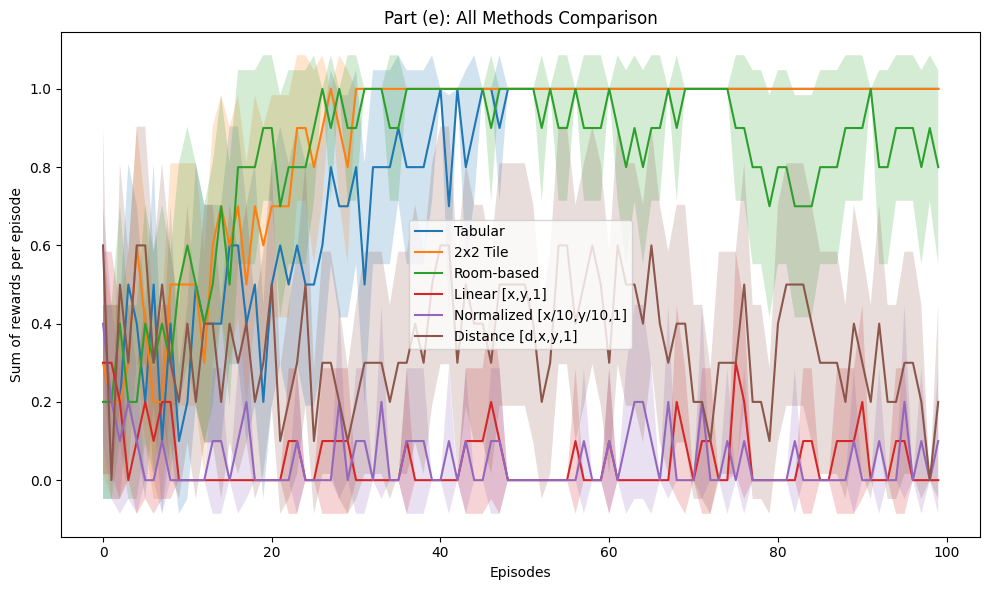

In [ ]:
def normalized_feature_encode(state, action, env):
    """
    Normalized features: [x/10, y/10, 1].
    Scales coordinates to [0,1] range for more stable gradient updates.
    Action incorporated via block-diagonal structure (d = 3 * |A| = 12).
    """
    x, y = state[0], state[1]
    base_features = np.array([x / 10.0, y / 10.0, 1.0])

    a_idx = list(env.action_space.keys()).index(action)
    num_actions = len(env.action_space)

    d = 3 * num_actions
    feature = np.zeros(d)
    feature[a_idx * 3 : (a_idx + 1) * 3] = base_features
    return feature

def distance_feature_encode(state, action, env):
    """
    Distance-augmented features: [d, x, y, 1] where d = BFS distance to goal.
    Provides strong domain knowledge about proximity to reward.
    Action incorporated via block-diagonal structure (d = 4 * |A| = 16).
    """
    x, y = state[0], state[1]
    dist = distance_matrix.get((x, y), 0)
    base_features = np.array([dist, x, y, 1.0])

    a_idx = list(env.action_space.keys()).index(action)
    num_actions = len(env.action_space)

    d = 4 * num_actions  #4 features * 4 actions = 16
    feature = np.zeros(d)
    feature[a_idx * 4 : (a_idx + 1) * 4] = base_features
    return feature

#run with normalized and distance features
print("Running Normalized [x/10, y/10, 1] SARSA...")
returns_norm = generate_learning_curve(
    env, normalized_feature_encode, semi_gradient_sarsa,
    episodes=100, runs=10, alpha=0.01
)

print("Running Distance [d, x, y, 1] SARSA...")
returns_dist = generate_learning_curve(
    env, distance_feature_encode, semi_gradient_sarsa,
    episodes=100, runs=10, alpha=0.001
)

#compare all linear features
plot_curves({
    "Linear [x,y,1]": returns_linear,
    "Normalized [x/10,y/10,1]": returns_norm,
    "Distance [d,x,y,1]": returns_dist
}, "Part (e): Linear Feature Comparison")

#compare everything
plot_curves({
    "Tabular": returns_tabular,
    "2x2 Tile": returns_tile,
    "Room-based": returns_room,
    "Linear [x,y,1]": returns_linear,
    "Normalized [x/10,y/10,1]": returns_norm,
    "Distance [d,x,y,1]": returns_dist
}, "Part (e): All Methods Comparison")

### Part (f): Scaled Four Rooms (Extra Credit)

We design larger versions of Four Rooms by subdividing each original grid cell into $k \times k$ sub-cells. Walls and doorways are expanded proportionally. This increases the state space by a factor of $k^2$, testing whether function approximation can handle larger domains where tabular methods struggle.

In [ ]:
class ScaledFourRooms(object):
    """
    A scaled-up version of Four Rooms.
    Each original cell is subdivided into k x k sub-cells.
    Walls and doorways scale proportionally.
    """
    def __init__(self, k=1):
        self.k = k
        #original 11x11 layout
        original_grid = np.array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                  [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                  [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                  [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                  [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                                  [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1],
                                  [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                  [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                  [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

        # scale up: each cell becomes k x k block
        self.grid_size = 11 * k
        self.four_room_space = np.kron(original_grid, np.ones((k, k), dtype=int))

        empty_cells = np.where(self.four_room_space == 0)
        self.state_space = [[col, self.grid_size - 1 - row]
                            for row, col in zip(empty_cells[0], empty_cells[1])]

        self.action_space = {'LEFT': np.array([-1, 0]),
                             'RIGHT': np.array([1, 0]),
                             'DOWN': np.array([0, -1]),
                             'UP': np.array([0, 1])}

        self.start_state = [0, 0]
        self.goal_state = [self.grid_size - 1, self.grid_size - 1]
        #scale max timesteps proportionally to state space
        self.max_time_steps = 459 * k * k
        self.t = 0

    def reset(self):
        state = self.start_state
        reward = 0
        done = False
        self.t = 0
        return state, reward, done

    def step(self, state, act):
        self.t += 1
        if np.random.uniform() < 0.2:
            if act == "LEFT" or act == "RIGHT":
                act = np.random.choice(["UP", "DOWN"], 1)[0]
            else:
                act = np.random.choice(["RIGHT", "LEFT"], 1)[0]

        next_state = self.take_action(state, act)
        reward = 1.0 if next_state == self.goal_state else 0.0

        if next_state == self.goal_state or self.t == self.max_time_steps:
            done = True
        else:
            done = False

        return next_state, reward, done

    def take_action(self, state, act):
        state = np.array(state)
        next_state = state + self.action_space[act]
        return next_state.tolist() if next_state.tolist() in self.state_space else state.tolist()

#test the scaled environment
for k in [1, 2, 3]:
    scaled_env = ScaledFourRooms(k)
    print(f"k={k}: grid={scaled_env.grid_size}x{scaled_env.grid_size}, "
          f"states={len(scaled_env.state_space)}, "
          f"goal={scaled_env.goal_state}")

k=1: grid=11x11, states=104, goal=[10, 10]
k=2: grid=22x22, states=416, goal=[21, 21]
k=3: grid=33x33, states=936, goal=[32, 32]



===== Scale k=1 =====
  Running Normalized features...


Runs:   0%|          | 0/5 [00:00<?, ?it/s]

  Running Tile features...


Runs:   0%|          | 0/5 [00:00<?, ?it/s]

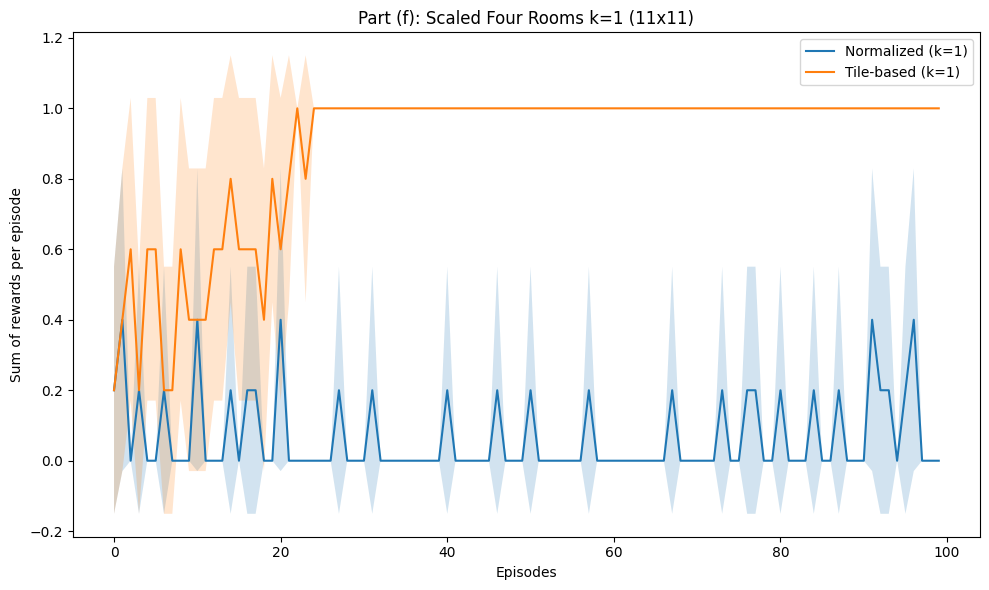


===== Scale k=2 =====
  Running Normalized features...


Runs:   0%|          | 0/5 [00:00<?, ?it/s]

  Running Tile features...


Runs:   0%|          | 0/5 [00:00<?, ?it/s]

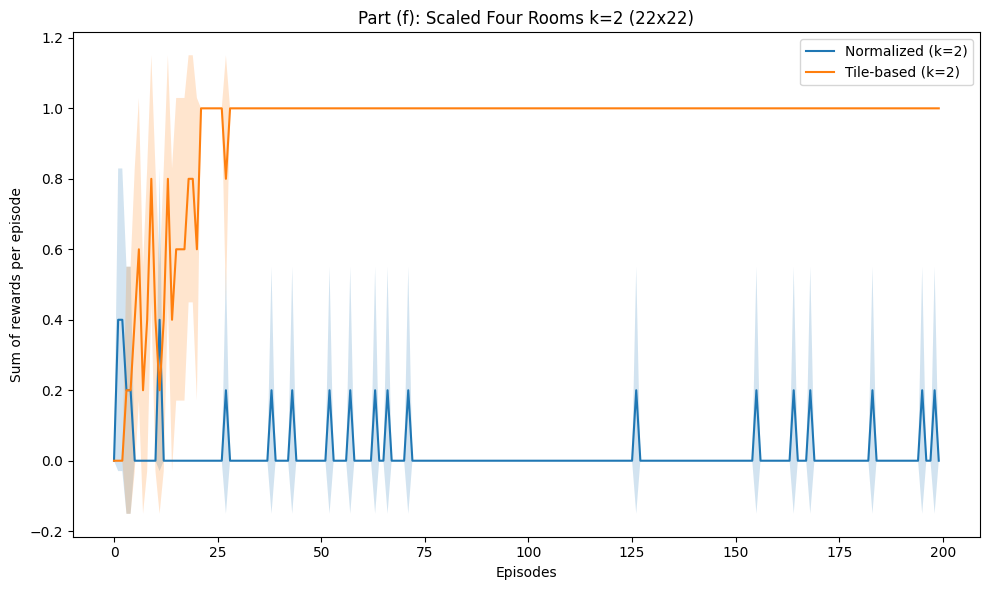

In [ ]:
def scaled_linear_xy1_encode(state, action, env):
    #Linear features [x, y, 1] adapted for scaled environments."""
    x, y = state[0], state[1]
    base_features = np.array([x, y, 1.0])
    a_idx = list(env.action_space.keys()).index(action)
    num_actions = len(env.action_space)
    d = 3 * num_actions
    feature = np.zeros(d)
    feature[a_idx * 3 : (a_idx + 1) * 3] = base_features
    return feature

def scaled_normalized_encode(state, action, env):
    #Normalized features [x/max, y/max, 1] for scaled environments."""
    max_coord = env.grid_size - 1
    x, y = state[0], state[1]
    base_features = np.array([x / max_coord, y / max_coord, 1.0])
    a_idx = list(env.action_space.keys()).index(action)
    num_actions = len(env.action_space)
    d = 3 * num_actions
    feature = np.zeros(d)
    feature[a_idx * 3 : (a_idx + 1) * 3] = base_features
    return feature

def scaled_tile_encode(state, action, env):
    #Tile-based encoding for scaled environments. Tile size = 2k."""
    tile_size = max(2, env.k * 2)
    max_coord = env.grid_size
    num_tiles_x = (max_coord + tile_size - 1) // tile_size
    num_tiles_y = (max_coord + tile_size - 1) // tile_size
    total_tiles = num_tiles_x * num_tiles_y

    tile_x = state[0] // tile_size
    tile_y = state[1] // tile_size
    tile_id = tile_y * num_tiles_x + tile_x

    a_idx = list(env.action_space.keys()).index(action)
    num_actions = len(env.action_space)
    d = total_tiles * num_actions
    feature = np.zeros(d)
    hot_idx = tile_id * num_actions + a_idx
    feature[hot_idx] = 1.0
    return feature

# Run experiments for k=1 and k=2
results_by_scale = {}

for k in [1, 2]:
    print(f"\n===== Scale k={k} =====")
    scaled_env = ScaledFourRooms(k)
    num_episodes = 100 * k  # more episodes for larger envs

    print(f"  Running Normalized features...")
    ret_norm = generate_learning_curve(
        scaled_env, scaled_normalized_encode, semi_gradient_sarsa,
        episodes=num_episodes, runs=5, alpha=0.01
    )

    print(f"  Running Tile features...")
    ret_tile = generate_learning_curve(
        scaled_env, scaled_tile_encode, semi_gradient_sarsa,
        episodes=num_episodes, runs=5, alpha=0.1
    )

    results_by_scale[k] = {
        "norm": ret_norm,
        "tile": ret_tile,
    }

    plot_curves({
        f"Normalized (k={k})": ret_norm,
        f"Tile-based (k={k})": ret_tile,
    }, f"Part (f): Scaled Four Rooms k={k} ({scaled_env.grid_size}x{scaled_env.grid_size})")